# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Evie McMahan

**Date:** 9/9/2026

## Q1 ##

See 'q1_answer' for my calculations.

## Q2 ##

### Step 1 ###

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/ForeignGifts_edu.csv")
print(df.shape)
df.head()


(28221, 10)


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


This dataset has 10 rows and 28,221 columns. It describes the foreign gifts donated to American universities. 

### Step 2 ###

In [2]:
print("number of values:", df['Foreign Gift Amount'].count()) # Describe shape 
print("number of null values:", df['Foreign Gift Amount'].isnull().sum())

print("value type:", df['Foreign Gift Amount'].dtype)

negative_values = (df['Foreign Gift Amount'] < 0).sum() # Sum number of negative donations
print("number of negative values:",f"{negative_values:,.0f}","\n")


print("mean: $",f"{df['Foreign Gift Amount'].mean():,.2f}") # Printing out summary statistics
print("median: $",f"{df['Foreign Gift Amount'].median():,.2f}")
print("mode: $",f"{df['Foreign Gift Amount'].mode().iloc[0]:,.2f}")
print("min: $",f"{df['Foreign Gift Amount'].min():,.2f}")
print("Q1: $",f"{df['Foreign Gift Amount'].quantile(.25):,.2f}")
print("Q2: $",f"{df['Foreign Gift Amount'].quantile(.75):,.2f}")
print("max: $",f"{df['Foreign Gift Amount'].max():,.2f}")

number of values: 28221
number of null values: 0
value type: int64
number of negative values: 24 

mean: $ 588,232.72
median: $ 94,615.00
mode: $ 100.00
min: $ -537,770.00
Q1: $ 5,700.00
Q2: $ 376,142.00
max: $ 99,999,999.00


The Foreign Gift Amount variable reports the dollar value that an American university received from a foreign entity for each gift. It is an integer value type, and there are 28,221 values within the variable (0 null values). The mean gift amount from a foreign entity is $588,232.72 and the median is $94,615, which implies the distribution is strongly right-skewed. I will confirm this in the histogram next. The most common gift was worth $100, and the minimum gift was -$537,770, while the maximum gift was $99,999,999. There are 24 gifts that are recorded as negative. These values could potentially reflect refunds. The middle 50% of gifts fall between $5,700 and $376,142. This variable shows a wide range of gift amounts recieved from foreign entities. 

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

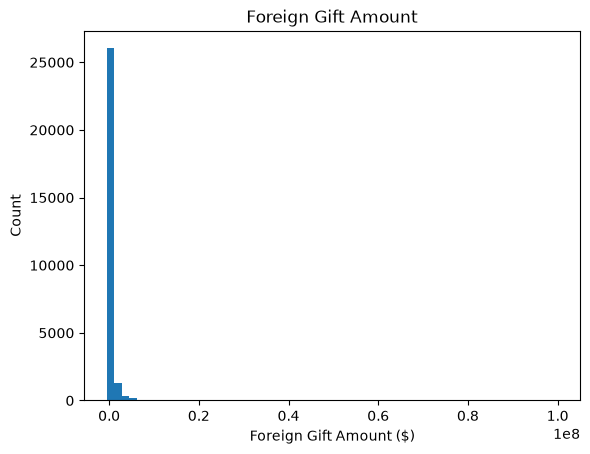

In [3]:
print(df['Foreign Gift Amount'].describe())

df['Foreign Gift Amount'].hist(bins=60, grid=False) # Create histogram
plt.title('Foreign Gift Amount')
plt.xlabel('Foreign Gift Amount ($)')
plt.ylabel('Count')
plt.show

The `Foreign Gift Amount` distribution confirms the strong right skew I inferred from the mean being so much larger than the median. The vast majority of gift amounts (well over 25,000 out of 28,221) fall into the first bin of the histogram, and the plot is skewed by extremely large, but sparce, gifts. This makes sense because the most common gift amount is $100 and 50% of gifts are less than $94,615, yet the largest gift was worth $99,999,999. The long tail makes the hisogram badly scaled, but the questions' instructions and Professor Lei said not to rescale the histogram, so I will leave it in it's linear form.

### Step 3 ###

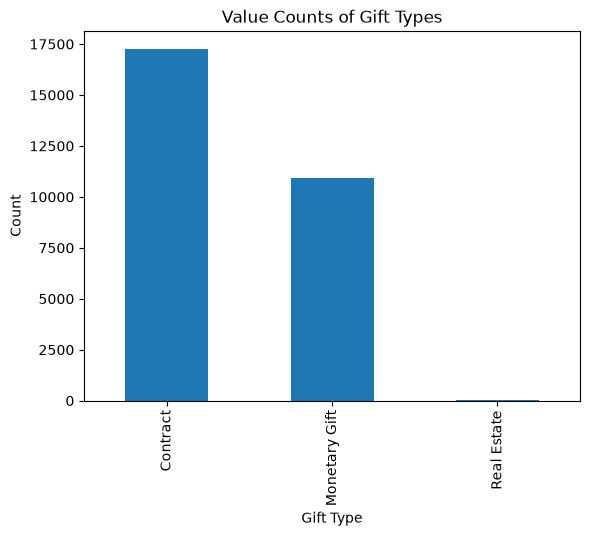

Proportions (in %):
Gift Type
Contract         61.21
Monetary Gift    38.75
Real Estate       0.04
Name: proportion, dtype: float64


In [4]:
counts = df['Gift Type'].value_counts() # Calculate value counts
proportions = round(df['Gift Type'].value_counts(normalize = True)*100,2) # Calculate Proportions

counts.plot(kind='bar') # Create the plot
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.title('Value Counts of Gift Types')
plt.show()

print('Proportions (in %):')
print(proportions) 

I chose to create a value count chart since the variable is categorical. 61.21% of gifts are contracts, 38.75% are monetary gifts, and 0.04% are real estate.

### Step 4 ###

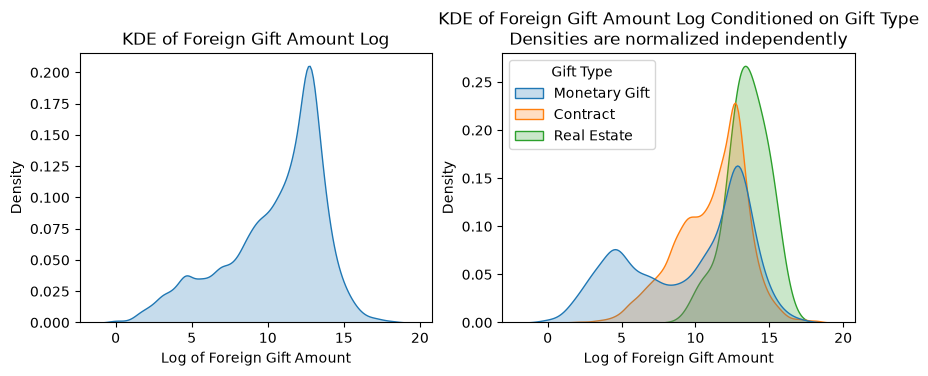

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5)) # Set up 2 subplots

positive_foreign_gifts = df.loc[df['Foreign Gift Amount'] > 0, 'Foreign Gift Amount'] # Extract positive values
df['foreign_gift_amount_log'] = np.log(positive_foreign_gifts) # Take the natural log of positive values
sns.kdeplot(x=df['foreign_gift_amount_log'], bw_method='silverman', fill=True, ax=axes[0]) # Plot first KDE
axes[0].set(
    title = "KDE of Foreign Gift Amount Log",
    xlabel = "Log of Foreign Gift Amount",
    ylabel = "Density"
)


sns.kdeplot(data=df,x=df['foreign_gift_amount_log'], bw_method='silverman', hue='Gift Type', common_norm=False, fill=True, ax=axes[1]) # Plot KDE conditioned on gift type
axes[1].set(
    title = "KDE of Foreign Gift Amount Log Conditioned on Gift Type\nDensities are normalized independently",
    xlabel = "Log of Foreign Gift Amount",
    ylabel = "Density"
)
plt.show()

Since there are only 24 negative values, and you can't take the log of a negative number, I decided to exclude those 24 values. For the KDE conditioned by `Gift Type`, I decided to use `commmon_norm=False` to normalize each density independently. Otherwise, there were so few real estate gifts that its KDE didn't appear on the plot. I notice that there is a spike in the density of the natural log of foreign gift amounts around 12-14 (which corresponds to ~$163,000 to $1,200,000). This is a much larger range in absolute dollars than it appears on the log scale. Real estate gifts tend to be larger and have a smaller range than contracts, while monetary gifts are frequently smaller but are by far the most dispersed. However, the number of values that each KDE is built off of differs by gift type (for example, only 0.04% of gifts are real estate). In general, the non-conditioned KDE most closely matches the KDE for contracts, which makes sense given that contracts make up 61% of gifts.

### Step 5 ###

In [6]:
country_gift_count = df['Foreign Gift Amount'].groupby(df['Country of Giftor']).count() # Count number of gifts by country
country_gift_count = country_gift_count.sort_values(ascending=False) # Sort descending
print(country_gift_count.head(15)) # Print top 15

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64


I referenced the `Foreign Gift Amount` to count my grouped countries on because I know it has no null values. The top 15 countries in terms of number of gifts are England (3,655), China (2,461), Canada (2,344), Japan (1,896), Switzerland (1,676), Saudi Arabia (1,610), France (1,437), Germany (1,394), Hong Kong (1,080), South Korea (811), Qatar (693), the Netherlands (512), Korea (452), India (434), and Taiwan (381).

In [7]:
country_amt_given = df['Foreign Gift Amount'].groupby(df['Country of Giftor']).sum() # Sum all of gifts by country
country_amt_given = country_amt_given.sort_values(ascending=False) # Sort descending
print(country_amt_given.head(15)) # Print top 15

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


The top 15 countries in terms of amount given are Qatar ($2,706,240,869), England ($1,464,906,771), China ($1,237,952,112), Saudi Arabia ($1,065,205,930), Bermuda ($899,593,972), Canada ($898,160,656), Hong Kong ($887,402,529), Japan ($655,954,776), Switzerland ($619,899,445), India ($539,556,490), Germany ($442,475,605), the United Arab Emirates ($431,396,357), France ($405,839,396), Singapore ($401,157,692), and Australia ($248,409,202).

### Step 6 ###

In [8]:
giftor_amt_given = df['Foreign Gift Amount'].groupby(df['Giftor Name']).sum() # Sum all of gifts by giftor
giftor_amt_given = giftor_amt_given.sort_values(ascending=False) # Sort descending
print(giftor_amt_given.head(10)) # Print top 6

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64



The top giftors that have provided the most money in total are the Qatar Foundation, which include some gifts co-donated with Qatar National Res, the Qatar Foundation for Eduction, the Saudi Arabian Cultural Mission, HCL, the Church of Jesus Christ of LSD, the Emirates Institute for Advanced Sc, and QIC. While the Anonymous group consists of multiple donors, Anonymous #9 is one donor who has also provided a substantial amount of gifts. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [9]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]